In [61]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import requests 
import io 
import joblib 
import os 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 

In [62]:
NHANES_BASE = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles"

urls = {
    "demo": f"{NHANES_BASE}/DEMO_J.XPT",
    "bmx":  f"{NHANES_BASE}/BMX_J.XPT",
    "dr1":  f"{NHANES_BASE}/DR1TOT_J.XPT",
    "dr2":  f"{NHANES_BASE}/DR2TOT_J.XPT", 
    "paq":  f"{NHANES_BASE}/PAQ_J.XPT",
    "slq":  f"{NHANES_BASE}/SLQ_J.XPT"   
}


In [63]:
def load_nhanes(name, url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=30)
    if response.status_code != 200:
        raise Exception(f"Failed to fetch {name}")
    if b"<html" in response.content[:100].lower():
        raise Exception(f"{name} returned HTML - URL is wrong or file moved")
    return pd.read_sas(io.BytesIO(response.content), format='xport', encoding='utf-8')

In [64]:
demo_data = load_nhanes("demo", urls["demo"])
bmx_data = load_nhanes("bmx", urls["bmx"])
diet1_data = load_nhanes("dr1", urls["dr1"])
diet2_data = load_nhanes("dr2", urls["dr2"])

In [65]:
paq_data = load_nhanes("paq", urls["paq"])

In [66]:
cols = ['SEQN','PAQ610', 'PAD615','PAQ625', 'PAD630', 'PAQ655', 'PAD660', 'PAQ670', 'PAD675']
paq_final = paq_data[cols]
paq_final['vig_met'] = (paq_final['PAQ610'] * paq_final['PAD615'] * 8) + (paq_final['PAQ655'] * paq_final['PAD660'] * 8)

# Calculate Moderate MET-minutes (Work + Recreation)
paq_final['mod_met'] = (paq_final['PAQ625'] * paq_final['PAD630'] * 4) + (paq_final['PAQ670'] * paq_final['PAD675'] * 4)

# Total Weekly MET-minutes
paq_final['total_met_min'] = paq_final['vig_met'].fillna(0) + paq_final['mod_met'].fillna(0)

In [67]:
paq_final.isnull().sum()

SEQN                0
PAQ610           4467
PAD615           4475
PAQ625           3417
PAD630           3430
PAQ655           4422
PAD660           4425
PAQ670           3548
PAD675           3555
vig_met          5411
mod_met          4711
total_met_min       0
dtype: int64

In [68]:
for col in cols:
    if col!='SEQN':
        paq_final.loc[paq_final[col] > 1440, col] = 0

In [69]:
demo_data = demo_data[["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3"]]
bmx_data = bmx_data[["SEQN", "BMXWT", "BMXHT", "BMXWAIST", "BMXHIP", "BMXARML"] ]

In [70]:
demo_data.shape, bmx_data.shape, paq_data.shape

((9254, 4), (8704, 6), (5856, 17))

In [71]:
metabolic_df = pd.merge(demo_data, bmx_data, on="SEQN", how="inner")

In [72]:
metabolic_df = pd.merge(metabolic_df, paq_final, on="SEQN", how="left")

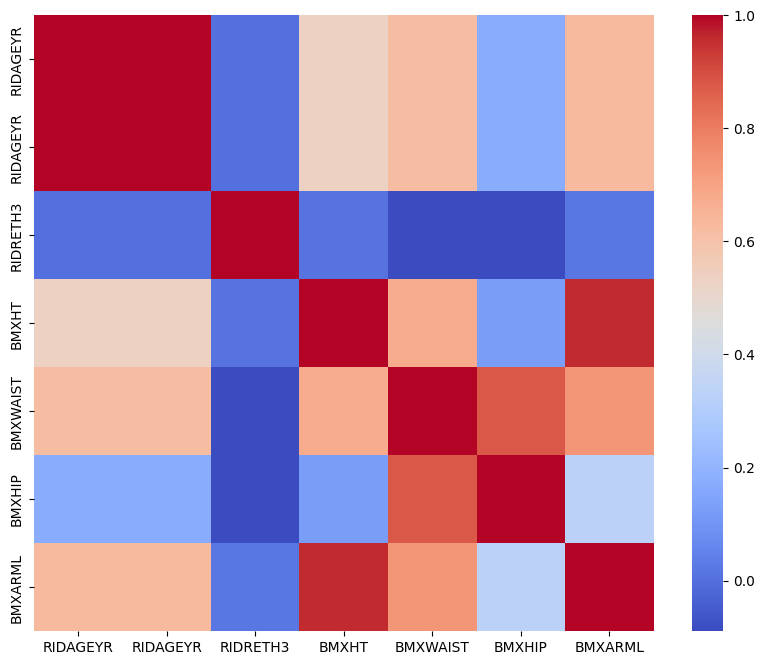

In [73]:
corr_cols = ["RIDAGEYR", "RIDAGEYR", "RIDRETH3", "BMXHT", "BMXWAIST", "BMXHIP", "BMXARML"]
correlation_matrix = metabolic_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.show()

In [74]:
def get_activity_multiplier(total_mins):
    if total_mins < 600: return 1.2 
    elif total_mins < 1499: return 1.375
    elif total_mins < 2999: return 1.55 
    else: return 1.725

In [76]:
metabolic_df['bmr'] = (10 * metabolic_df['BMXWT']) + (6.25 * metabolic_df['BMXHT']) - (5 * metabolic_df['RIDAGEYR'])
metabolic_df.loc[metabolic_df['RIAGENDR'] == 1, 'bmr'] += 5
metabolic_df.loc[metabolic_df['RIAGENDR'] == 2, 'bmr'] -= 161

In [77]:
metabolic_df["act_mult"] = metabolic_df["total_met_min"].apply(get_activity_multiplier)
metabolic_df["tdee"] = metabolic_df["bmr"] * metabolic_df["act_mult"]

In [78]:
def two_day_ave(df, col1, col2):
    return (df[col1] + df[col2]) / 2

In [79]:
cols1 = ["SEQN", "DR1TKCAL", "DR1TPROT", "DR1TTFAT", "DR1TCARB", "DR1TSUGR", "DR1TFIBE"]
cols2 = ["SEQN", "DR2TKCAL", "DR2TPROT", "DR2TTFAT", "DR2TCARB", "DR2TSUGR", "DR2TFIBE"]
dietary = diet1_data[cols1].merge(diet2_data[cols2], on="SEQN", how="left")

In [80]:
dietary["calories"] = two_day_ave(dietary, "DR1TKCAL", "DR2TKCAL")
dietary["protein_g"] = two_day_ave(dietary, "DR1TPROT", "DR2TPROT")
dietary["fat_g"] = two_day_ave(dietary, "DR1TTFAT", "DR2TTFAT")
dietary["carb_g"] = two_day_ave(dietary, "DR1TCARB", "DR2TCARB")
dietary["sugar_g"]  = two_day_ave(dietary, "DR1TSUGR", "DR2TSUGR")
dietary["fiber_g"]  = two_day_ave(dietary, "DR1TFIBE", "DR2TFIBE")

In [81]:
nutrients = ["calories", "protein_g", "fat_g", "carb_g", "sugar_g", "fiber_g"]
dietary = dietary[["SEQN", "calories", "protein_g", "fat_g", "carb_g", "sugar_g", "fiber_g"]]

In [82]:
final_df = metabolic_df.merge(dietary, on="SEQN", how="inner")

In [83]:
#Drop rows with missing weight or height 
(final_df["BMXWT"].isnull() | final_df["BMXHT"].isnull()).sum()
print(final_df.shape)
final_df = final_df.dropna(subset=['BMXWT', 'BMXHT'], how='any')
print(final_df.shape)

(8704, 29)
(8005, 29)


In [84]:
final_df.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'BMXWT', 'BMXHT',
       'BMXWAIST', 'BMXHIP', 'BMXARML', 'PAQ610', 'PAD615', 'PAQ625', 'PAD630',
       'PAQ655', 'PAD660', 'PAQ670', 'PAD675', 'vig_met', 'mod_met',
       'total_met_min', 'act_mult', 'bmr', 'tdee', 'calories', 'protein_g',
       'fat_g', 'carb_g', 'sugar_g', 'fiber_g'],
      dtype='str')

In [85]:
final_df["sur_def"] = final_df["calories"] - final_df["tdee"]
final_df["weight_change_7d"] = (final_df["sur_def"] * 7) / 7700
final_df["weight_change_7d"] += np.random.normal(0, 0.3, size=len(final_df))

In [86]:
final_df = final_df.dropna(subset='calories')

In [87]:
final_df.isnull().sum()

SEQN                   0
RIDAGEYR               0
RIAGENDR               0
RIDRETH3               0
BMXWT                  0
BMXHT                  0
BMXWAIST             173
BMXHIP              1223
BMXARML              107
PAQ610              5053
PAD615              5058
PAQ625              4217
PAD630              4225
PAQ655              5020
PAD660              5021
PAQ670              4368
PAD675              4370
vig_met             5776
mod_met             5215
total_met_min       1812
act_mult               0
bmr                    0
tdee                   0
calories               0
protein_g              0
fat_g                  0
carb_g                 0
sugar_g                0
fiber_g                0
sur_def                0
weight_change_7d       0
dtype: int64

In [88]:
target = final_df['weight_change_7d']
X = final_df.drop(['SEQN', 'weight_change_7d'], axis=1)

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=42)
X_train

,RIDAGEYR,RIAGENDR,RIDRETH3,BMXWT,BMXHT,BMXWAIST,BMXHIP,BMXARML,PAQ610,PAD615,...,act_mult,bmr,tdee,calories,protein_g,fat_g,carb_g,sugar_g,fiber_g,sur_def
5952,63.0,2.0,4.0,78.2,179.8,90.1,102.1,40.6,NaN,NaN,...,1.200,1429.750,1715.7000,1822.0,49.230,87.950,218.435,113.440,15.55,106.3000
6567,5.0,2.0,4.0,20.1,111.2,52.2,NaN,24.0,NaN,NaN,...,1.725,710.000,1224.7500,2299.0,63.010,84.610,329.780,134.450,18.65,1074.2500
2157,69.0,1.0,6.0,78.8,170.3,99.3,106.6,39.2,NaN,NaN,...,1.200,1512.375,1814.8500,1544.5,78.710,49.425,198.080,46.195,21.90,-270.3500
1036,66.0,2.0,6.0,60.0,153.3,92.3,93.4,36.1,NaN,NaN,...,1.200,1067.125,1280.5500,1308.0,75.265,38.540,169.505,37.555,19.25,27.4500
3112,20.0,1.0,3.0,66.1,181.6,73.9,94.0,41.0,1.0,30.0,...,1.200,1701.000,2041.2000,2577.0,101.350,113.095,294.300,154.255,12.80,535.8000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5417,80.0,2.0,3.0,57.3,151.0,99.5,97.2,36.0,NaN,NaN,...,1.200,955.750,1146.9000,1675.5,65.785,74.160,197.155,79.080,18.90,528.6000
7391,75.0,2.0,3.0,82.2,163.2,108.0,109.9,39.5,NaN,NaN,...,1.200,1306.000,1567.2000,1436.5,87.765,76.635,100.195,36.055,12.35,-130.7000
7435,19.0,1.0,2.0,54.9,171.2,67.9,82.0,36.3,6.0,420.0,...,1.725,1529.000,2637.5250,2868.0,123.850,120.080,330.270,166.980,17.60,230.4750
7673,21.0,2.0,6.0,88.5,154.2,105.2,116.6,34.5,NaN,NaN,...,1.200,1582.750,1899.3000,1194.5,27.955,55.800,144.500,63.990,7.75,-704.8000


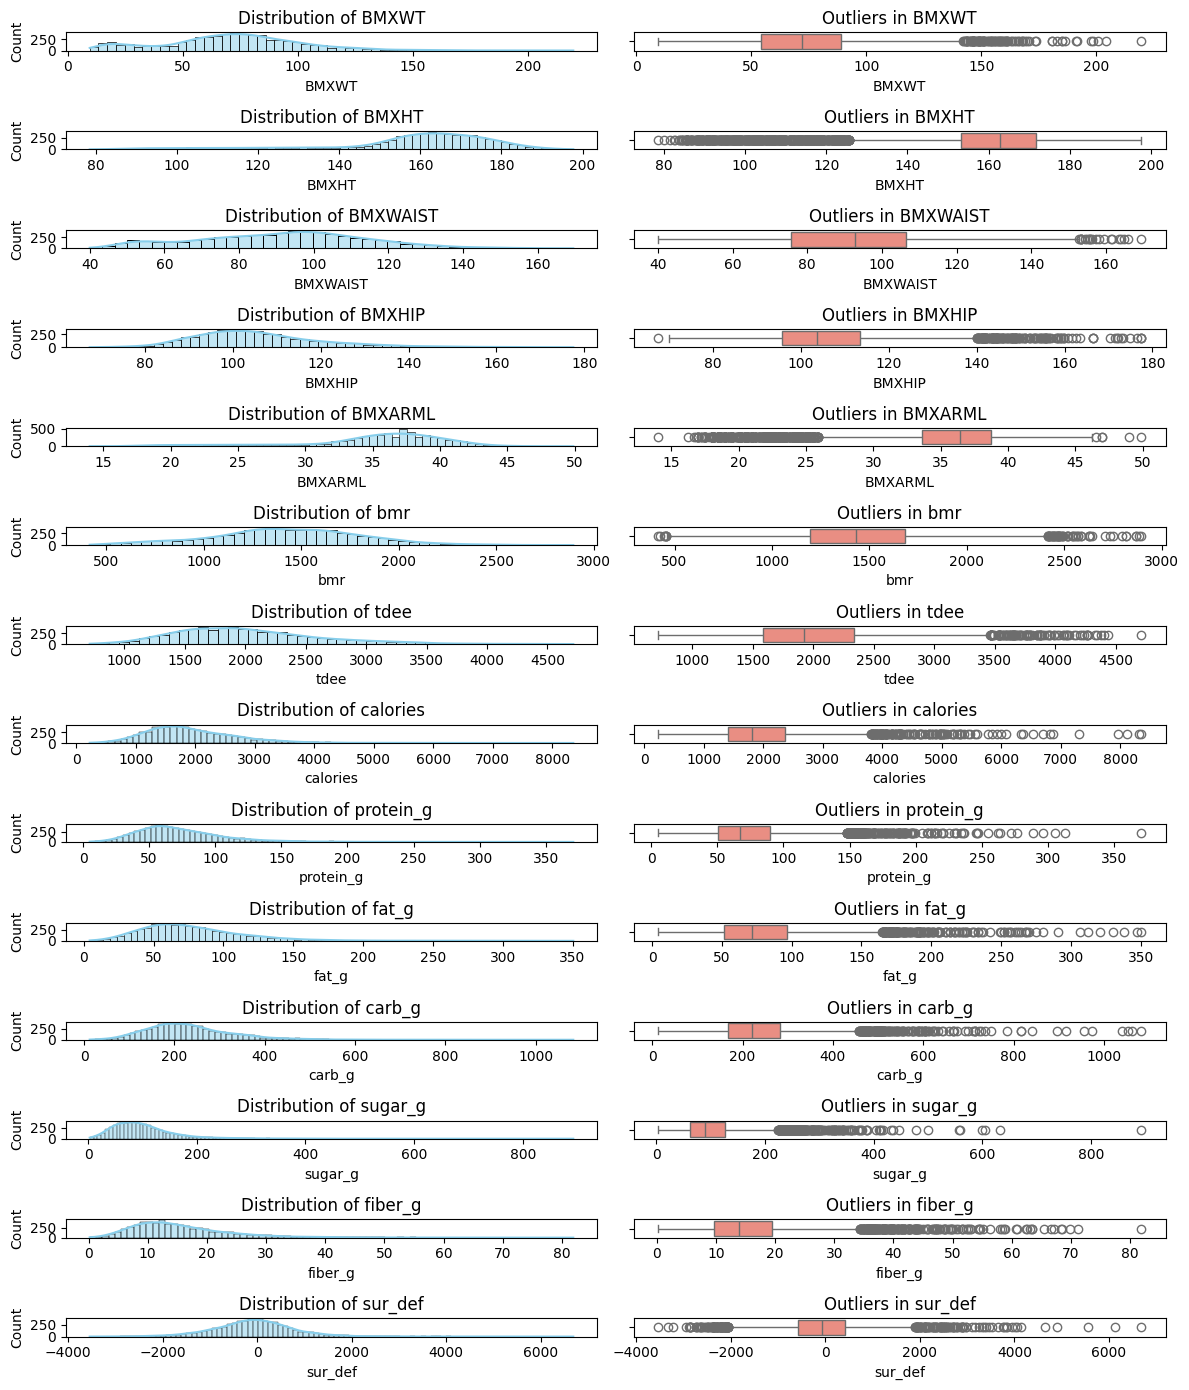

In [92]:
num_cols = ['BMXWT', 'BMXHT',
       'BMXWAIST', 'BMXHIP', 'BMXARML', 'bmr', 'tdee',
       'calories', 'protein_g', 'fat_g', 'carb_g', 'sugar_g', 'fiber_g',
       'sur_def']
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(X[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f"Distribution of {col}")

    sns.boxplot(x=X[col], ax=axes[i, 1], color="salmon")
    axes[i, 1].set_title(f"Outliers in {col}")

plt.tight_layout()

In [93]:
# Feature Skewness 
skewness = X[num_cols].skew().sort_values(ascending=False)
skewed_cols = skewness[skewness > 1].index
normal_cols = skewness[skewness.between(-1, 1)].index
neg_skewed_cols = skewness[skewness < -1].index
cat_cols = ['RIAGENDR', 'RIDRETH3']

In [94]:
skew_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one")), 
    ('scale', StandardScaler())
])

In [98]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skew', skew_pipeline, skewed_cols), 
        ('norm', Pipeline([
            ('imputer', SimpleImputer(strategy='median')), 
            ('scale', StandardScaler())
        ]), normal_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [ ]:
X_train_final.shape #Final 20 features 
# np.mean(X_train_final[:, :5], axis=0).round(2)
# np.std(X_train_final[:, :5], axis=0).round(2)

(4886, 20)

In [106]:
X_train.columns

Index(['RIDAGEYR', 'RIAGENDR', 'RIDRETH3', 'BMXWT', 'BMXHT', 'BMXWAIST',
       'BMXHIP', 'BMXARML', 'PAQ610', 'PAD615', 'PAQ625', 'PAD630', 'PAQ655',
       'PAD660', 'PAQ670', 'PAD675', 'vig_met', 'mod_met', 'total_met_min',
       'act_mult', 'bmr', 'tdee', 'calories', 'protein_g', 'fat_g', 'carb_g',
       'sugar_g', 'fiber_g', 'sur_def'],
      dtype='str')

In [100]:
assert X_train_final.shape[0] == len(y_train), "Row mismatch!"

In [101]:
feature_names = preprocessor.get_feature_names_out()
print("Total features: ", len(feature_names))
feature_names

Total features:  20


array(['skew__sugar_g', 'skew__fiber_g', 'skew__carb_g',
       'skew__protein_g', 'skew__calories', 'skew__fat_g', 'norm__BMXHIP',
       'norm__tdee', 'norm__sur_def', 'norm__BMXWT', 'norm__bmr',
       'norm__BMXWAIST', 'cat__RIAGENDR_1.0', 'cat__RIAGENDR_2.0',
       'cat__RIDRETH3_1.0', 'cat__RIDRETH3_2.0', 'cat__RIDRETH3_3.0',
       'cat__RIDRETH3_4.0', 'cat__RIDRETH3_6.0', 'cat__RIDRETH3_7.0'],
      dtype=object)

In [102]:
final_df[['BMXWT', 'BMXWAIST', 'BMXHIP']].corr()
preprocessor.get_feature_names_out()

array(['skew__sugar_g', 'skew__fiber_g', 'skew__carb_g',
       'skew__protein_g', 'skew__calories', 'skew__fat_g', 'norm__BMXHIP',
       'norm__tdee', 'norm__sur_def', 'norm__BMXWT', 'norm__bmr',
       'norm__BMXWAIST', 'cat__RIAGENDR_1.0', 'cat__RIAGENDR_2.0',
       'cat__RIDRETH3_1.0', 'cat__RIDRETH3_2.0', 'cat__RIDRETH3_3.0',
       'cat__RIDRETH3_4.0', 'cat__RIDRETH3_6.0', 'cat__RIDRETH3_7.0'],
      dtype=object)

In [103]:
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(X_train_final, '../data/processed/X_train_scaled.pkl')
joblib.dump(X_test_final, '../data/processed/X_test_scaled.pkl')
joblib.dump(y_train, '../data/processed/y_train.pkl')
joblib.dump(y_test, '../data/processed/y_test.pkl')

joblib.dump(preprocessor, '../models/preprocessor.pkl')

['../models/preprocessor.pkl']